In [ ]:
# s4U-pulsed, MITO-PRADA under labeling conditions BP+DF --- --- 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO
from sklearn import metrics 

In [4]:
## 1. Extend Figure 7m-7r --- --- 
### 1_1. Extend Fig7m --- --- 
### 1_2. Extend Fig7n_7o --- --- 
### 1_3. Extend Fig7p_7q_7r --- --- 

In [ ]:
### 1_1. Extend Fig5m --- --- 

In [2]:
dir = "./Data/"
s4U_prada = pd.read_csv(dir+"s4U_PRADA_BPDF_heavy_NC_012920.1_profile.txt",sep='\t')

s4U_prada_label = s4U_prada[s4U_prada['Modified_effective_depth'] >=5000]
print(s4U_prada.shape)
print(s4U_prada_label.shape)
s4U_prada_label = s4U_prada_label[['Nucleotide','Sequence','Modified_rate']]
s4U_prada_label.columns=['Nucleotide','Sequence','mod_rate']
s4U_prada_label['group'] = 'Label'

s4U_prada_ctrl = s4U_prada[s4U_prada['Untreated_effective_depth'] >=5000]
print(s4U_prada.shape)
print(s4U_prada_ctrl.shape)
s4U_prada_ctrl = s4U_prada_ctrl[['Nucleotide','Sequence','Untreated_rate']]
s4U_prada_ctrl.columns=['Nucleotide','Sequence','mod_rate']
s4U_prada_ctrl['group'] = 'Ctrl'

s4U_prada_flt = pd.concat([s4U_prada_label,s4U_prada_ctrl])
dplot = s4U_prada_flt 

dplot.to_csv('./Data/'+'source_data_Efig7m.csv',sep=',') 

(16569, 29)
(12115, 29)
(16569, 29)
(11613, 29)


G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.399e-81 U_stat=1.604e+06
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=7.190e+06
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.317e-08 U_stat=6.916e+06
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.176e-201 U_stat=9.997e+06
                mod_rate
Sequence group          
A        Ctrl   0.000086
         Label  0.000090
C        Ctrl   0.000423
         Label  0.000635
G        Ctrl   0.000417
         Label  0.000826
N        Ctrl   0.002539
U        Ctrl   0.000823
         Label  0.001994


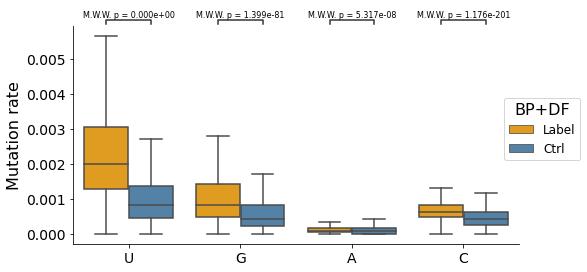

In [3]:
#### plot --- --- 

plt.figure(figsize=(8,4))
order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}

ax = sns.boxplot(data=dplot, x='Sequence',y='mod_rate', hue='group',showfliers = False,order = order, palette = my_pal)     
plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Mutation rate',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='BP+DF',bbox_to_anchor=(1.15, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='Sequence',y='mod_rate', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl'))
                                ],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig7m_s4U_PRADA_BPDF_mutrate_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['Sequence','group']).median()[['mod_rate']])  

In [5]:
print(dplot.groupby(['Sequence','group']).mean()[['mod_rate']])  

                mod_rate
Sequence group          
A        Ctrl   0.002689
         Label  0.001804
C        Ctrl   0.001778
         Label  0.002752
G        Ctrl   0.002912
         Label  0.005383
N        Ctrl   0.002539
U        Ctrl   0.001430
         Label  0.002735


In [6]:
print(dplot.groupby(["Sequence", "group"]).count())  

                Nucleotide  mod_rate
Sequence group                      
A        Ctrl         3537      3537
         Label        3631      3631
C        Ctrl         3578      3578
         Label        3981      3981
G        Ctrl         1576      1576
         Label        1450      1450
N        Ctrl            1         1
U        Ctrl         2921      2921
         Label        3053      3053


In [ ]:
### 1_2. Extend Fig5n_5o --- --- 

In [4]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

/tmp/ipykernel_14084/4282695278.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_14084/4282695278.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wi

(1605, 8)
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.271e-15 U_stat=2.341e+04
        Nucleotide  Sequence  Modified_effective_depth  \
region                                                   
DS              94        94                        94   
SS             324       324                       324   

        Untreated_effective_depth  Modified_rate  Untreated_rate  \
region                                                             
DS                             94             94              94   
SS                            324            324             324   

        Reactivity_profile  Norm_profile  Position2  base  dot  strand  
region                                                                  
DS                      94            94         94    94   94  

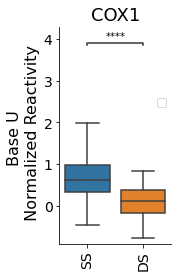

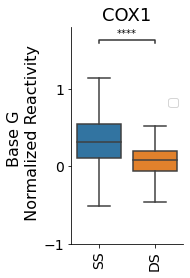

In [5]:
#### normalzied reactivity --- --- 

dir = "./Data/"
s4U_prada = pd.read_csv(dir+"s4U_PRADA_BPDF_heavy_NC_012920.1_profile.txt",sep='\t')
s4U_prada = s4U_prada[(s4U_prada['Modified_effective_depth'] >=5000) & (s4U_prada['Untreated_effective_depth'] >=5000)]
cox1= s4U_prada[(s4U_prada['Nucleotide']>=5900) & (s4U_prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899 
cox1['Position2'] =cox1['Nucleotide']

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

df = pd.merge(cox1,bench, how='left',on=['Position2','Position2']) 
dplot=df
tmp1 = dplot[dplot['strand'] == 1]
tmp1['region'] = 'SS'
tmp2 = dplot[dplot['strand'] == 0]
tmp2['region'] = 'DS'
dplot = pd.concat([tmp1,tmp2], ignore_index=True)

#### plots Base U --------------------------------

dplott = dplot[(dplot['base'] =='T') | (dplot['base'] =='U')]
dplott.to_csv('./Data/'+'source_data_Efig7n.csv',sep=',')

plt.figure(figsize=(2,4))
order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 
plt.title('COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base U \n Normalized Reactivity',fontsize = 16)
plt.xticks(fontsize = 14,rotation=90) 
plt.yticks(fontsize = 14)
#plt.yticks([-2.0,-1.0, 0.0, 1.0,2.0],fontsize = 14)  
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='star', loc='inside', line_offset_to_box=0.1, verbose=3)  

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig7n_s4U_PRADA_BPDF_baseU_SS_vs_DS.pdf',bbox_inches='tight', dpi=300)
print(dplott.groupby(["region"]).count())   

#### plots Base G --------------------------------

dplott = dplot[(dplot['base'] =='G')]
dplott.to_csv('./Data/'+'source_data_Efig7o.csv',sep=',')

plt.figure(figsize=(2,4))
order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 
plt.title('COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base G \n Normalized Reactivity',fontsize = 16)
plt.xticks(fontsize = 14,rotation=90) 
plt.yticks([-1.0, 0.0, 1.0],fontsize = 14) 
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='star', loc='inside', line_offset_to_box=0.1, verbose=3)  

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig7o_s4U_PRADA_BPDF_baseG_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 
print(dplott.groupby(["region"]).count())  

In [ ]:
### 1_3. Extend Fig5p_5q_5r --- --- 

(1605, 8)
0.7685185185185186
0.7417810218978103
0.7889152421446408


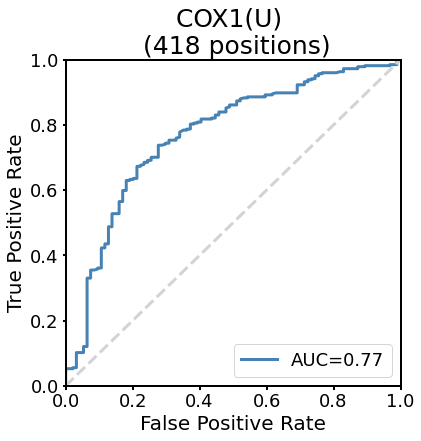

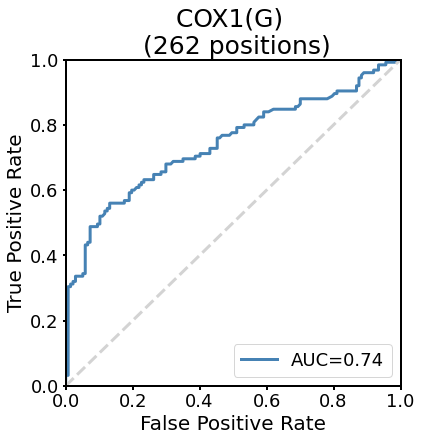

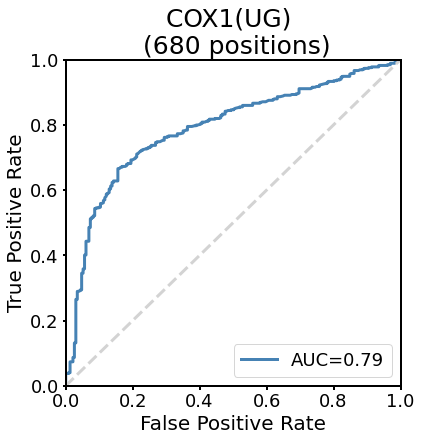

In [6]:
dir = "./Data/"
s4U_prada = pd.read_csv(dir+"s4U_PRADA_BPDF_heavy_NC_012920.1_profile.txt",sep='\t')
s4U_prada = s4U_prada[(s4U_prada['Modified_effective_depth'] >=5000) & (s4U_prada['Untreated_effective_depth'] >=5000)]
cox1= s4U_prada[(s4U_prada['Nucleotide']>=5900) & (s4U_prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899 
cox1['Position2'] =cox1['Nucleotide']

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

df = pd.merge(cox1,bench, how='left',on=['Position2','Position2']) 

## plot U--------------------------

flt=df[(df['base']=='T')]
flt.to_csv('./Data/'+'source_data_Efig7p_auroc.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('COX1(U) '+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig7p_s4U_PRADA_BPDF_baseU_AUROC.pdf',bbox_inches='tight', dpi=300) 


## plot G--------------------------

flt=df[(df['base']=='G')]
flt.to_csv('./Data/'+'source_data_Efig7q_auroc.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('COX1(G) '+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig7q_s4U_PRADA_BPDF_baseG_AUROC.pdf',bbox_inches='tight', dpi=300) 


## plot UG--------------------------

flt=df[(df['base']=='G') | (df['base']=='T')]
flt.to_csv('./Data/'+'source_data_Efig7r_auroc.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('COX1(UG) '+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig7r_s4U_PRADA_BPDF_baseUG_AUROC.pdf',bbox_inches='tight', dpi=300) 

